In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GATConv
import matplotlib.pyplot as plt
import os
import os.path as osp

# 【数据加载】

# 在 Jupyter 中，os.getcwd() 获取的是当前 .ipynb 文件所在的文件夹
current_dir = os.getcwd()
path = osp.join(current_dir, 'data', 'Cora')

print(f"当前搜索路径: {path}")

# 检查 raw 文件夹是否存在，避免触发 download()
raw_path = osp.join(path, 'raw')
if osp.exists(raw_path):
    print("找到本地 raw 文件夹，准备加载...")
else:
    print("错误：未找到数据！请确保 data 文件夹与此 Notebook 在同一目录下。")

# 加载数据集
dataset = Planetoid(root=path, name='Cora')
data = dataset[0]

print(f'\n成功加载！')
print(f'节点数: {data.num_nodes}, 边数: {data.num_edges}')

print(f'特征维度: {dataset.num_features}, 类别数: {dataset.num_classes}')


当前搜索路径: /home/malina/mln_work/GAT+Sample/data/Cora
找到本地 raw 文件夹，准备加载...

成功加载！
节点数: 2708, 边数: 10556
特征维度: 1433, 类别数: 7


In [4]:
# 【2. 模型定义】
class GAT(torch.nn.Module):
    def __init__(self, in_size, hidden_size, out_size):
        super(GAT, self).__init__()
        # 第一层：输入特征 -> 隐藏层 (使用 8 个注意力头)
        self.conv1 = GATConv(in_size, hidden_size, heads=8, dropout=0.6)
        # 第二层：多头拼接后的维度是 hidden_size * 8 -> 最终分类数
        self.conv2 = GATConv(hidden_size * 8, out_size, heads=1, concat=False, dropout=0.6)

    def forward(self, x, edge_index):
        # ELU 是常用的激活函数，类似 ReLU 但在负数区域更平滑
        x = F.elu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.conv2(x, edge_index)
        # 返回对数概率，用于计算损失
        return F.log_softmax(x, dim=1)


In [5]:
# 【3. 训练准备】
model = GAT(in_size=dataset.num_features, hidden_size=8, out_size=dataset.num_classes)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
losses = []

# 【4. 训练与评价函数】
def test():
    model.eval() # 切换到评估模式（关闭 Dropout）
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1) # 找到概率最大的类别
    
    # 分别计算训练集、验证集和测试集的准确率
    accs = []
    for mask in [data.train_mask, data.val_mask, data.test_mask]:
        correct = pred[mask] == data.y[mask]
        accs.append(int(correct.sum()) / int(mask.sum()))
    return accs

# 【5. 启动训练循环】
print("\n开始训练...")
for epoch in range(1, 101):
    model.train()
    optimizer.zero_grad()
    # 前向传播
    out = model(data.x, data.edge_index)
    # 计算损失 (只针对有标签的训练节点)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    # 反向传播与优化
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    
    if epoch % 10 == 0:
        train_acc, val_acc, test_acc = test()
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Test Acc: {test_acc:.4f}')


开始训练...
Epoch: 010, Loss: 1.0889, Test Acc: 0.7930
Epoch: 020, Loss: 0.6779, Test Acc: 0.7870
Epoch: 030, Loss: 0.6457, Test Acc: 0.7730
Epoch: 040, Loss: 0.4654, Test Acc: 0.7850
Epoch: 050, Loss: 0.4907, Test Acc: 0.7970
Epoch: 060, Loss: 0.3875, Test Acc: 0.7960
Epoch: 070, Loss: 0.3886, Test Acc: 0.7850
Epoch: 080, Loss: 0.3470, Test Acc: 0.7920
Epoch: 090, Loss: 0.3670, Test Acc: 0.7870
Epoch: 100, Loss: 0.4213, Test Acc: 0.7910


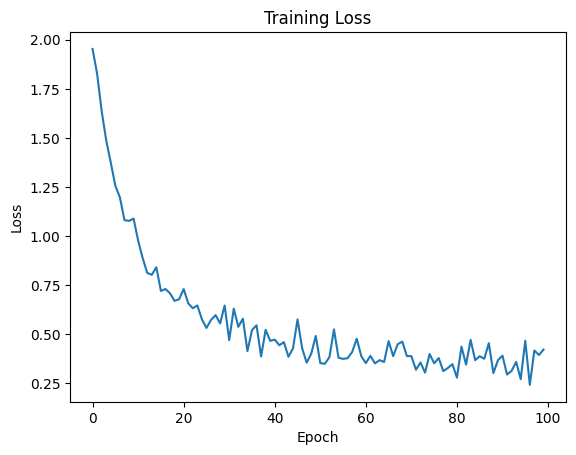


前10个节点的预测类别: [3, 4, 4, 0, 3, 2, 0, 3, 3, 2, 0, 0, 4, 3, 3]
前10个节点的真实类别: [3, 4, 4, 0, 3, 2, 0, 3, 3, 2, 0, 0, 4, 3, 3]


In [ ]:
# 【6. 结果查看：损失曲线】
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# 【7. 查看具体的分类结果】
model.eval()
logits = model(data.x, data.edge_index)
preds = logits.argmax(dim=1)
print(f"\n前10个节点的预测类别: {preds[:20].tolist()}")
print(f"前10个节点的真实类别: {data.y[:20].tolist()}")